## Exercise 1: Exploring Overfitting and Underfitting (Scikit-learn, Numpy, Matplotlib)

This exercise is based on the discussion of *overfitting* and *underfitting*: you will visualize how model complexity affects performance on training and validation data.

**Tasks:**
1.  Generate a synthetic dataset. Create a 1D non-linear function (e.g., `y = sin(x)`) and add some random noise to the `y` values.
2.  Split your data into a training set and a test set using `sklearn.model_selection.train_test_split`.
3.  Create a loop that fits polynomial regression models of increasing complexity (from degree 1 to 20).
    *   Inside the loop, use `sklearn.preprocessing.PolynomialFeatures` to create polynomial features, followed by `sklearn.linear_model.LinearRegression`.
4.  For each degree:
    *   Train the model on the training data.
    *   Calculate and store the Mean Squared Error (MSE) on both the **training set** and the **test set**.
5.  Plot the training MSE and test MSE as a function of the polynomial degree. You should see the training error continuously decrease and the test error decrease initially and then start increasing (forming a U-shape).
6.  Identify the approximate polynomial degree that represents a good trade-off (the "sweet spot" before overfitting begins).

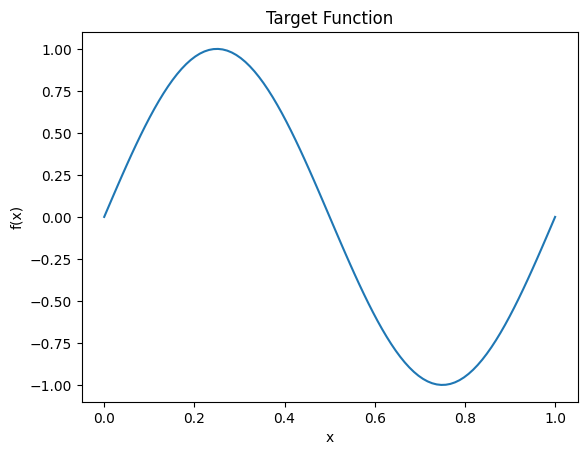

In [2]:
import numpy as np

def target_function(x):
    return np.sin(2*np.pi*x) 

import matplotlib.pyplot as plt
x = np.linspace(0, 1, 100)
y = target_function(x)
plt.plot(x, y)
plt.title("Target Function")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()


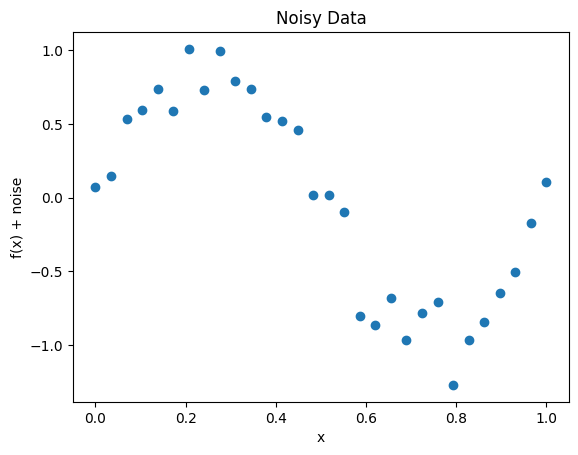

In [9]:
noise_std = 0.15

# add random gaussian noise to the target function
X = np.linspace(0, 1, 30)
y = target_function(X) + np.random.normal(0, noise_std, X.shape[0])
X = X.reshape(-1, 1)
plt.scatter(X, y)
plt.title("Noisy Data")
plt.xlabel("x")
plt.ylabel("f(x) + noise")
plt.show()

In [26]:
import sklearn
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.33, random_state=42)

Text(0, 0.5, 'f(x) + noise')

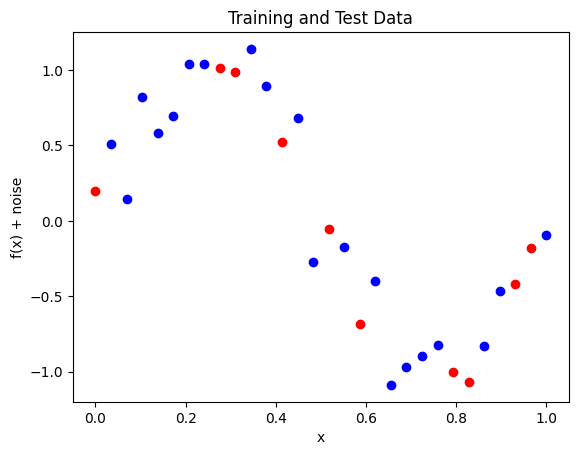

In [6]:
plt.scatter(X_train, y_train, color='blue', label='Training Data')
plt.scatter(X_test, y_test, color='red', label='Test Data')
plt.title("Training and Test Data")
plt.xlabel("x")
plt.ylabel("f(x) + noise")

In [11]:
class LeastSquares:
    def __init__(self):
        self._coef = None

    def fit(self, X, y):
        self._coef = np.linalg.inv(X.T @ X) @ X.T @ y

    def predict(self, X):
        return X @ self._coef

#### Plotting fitted models and data

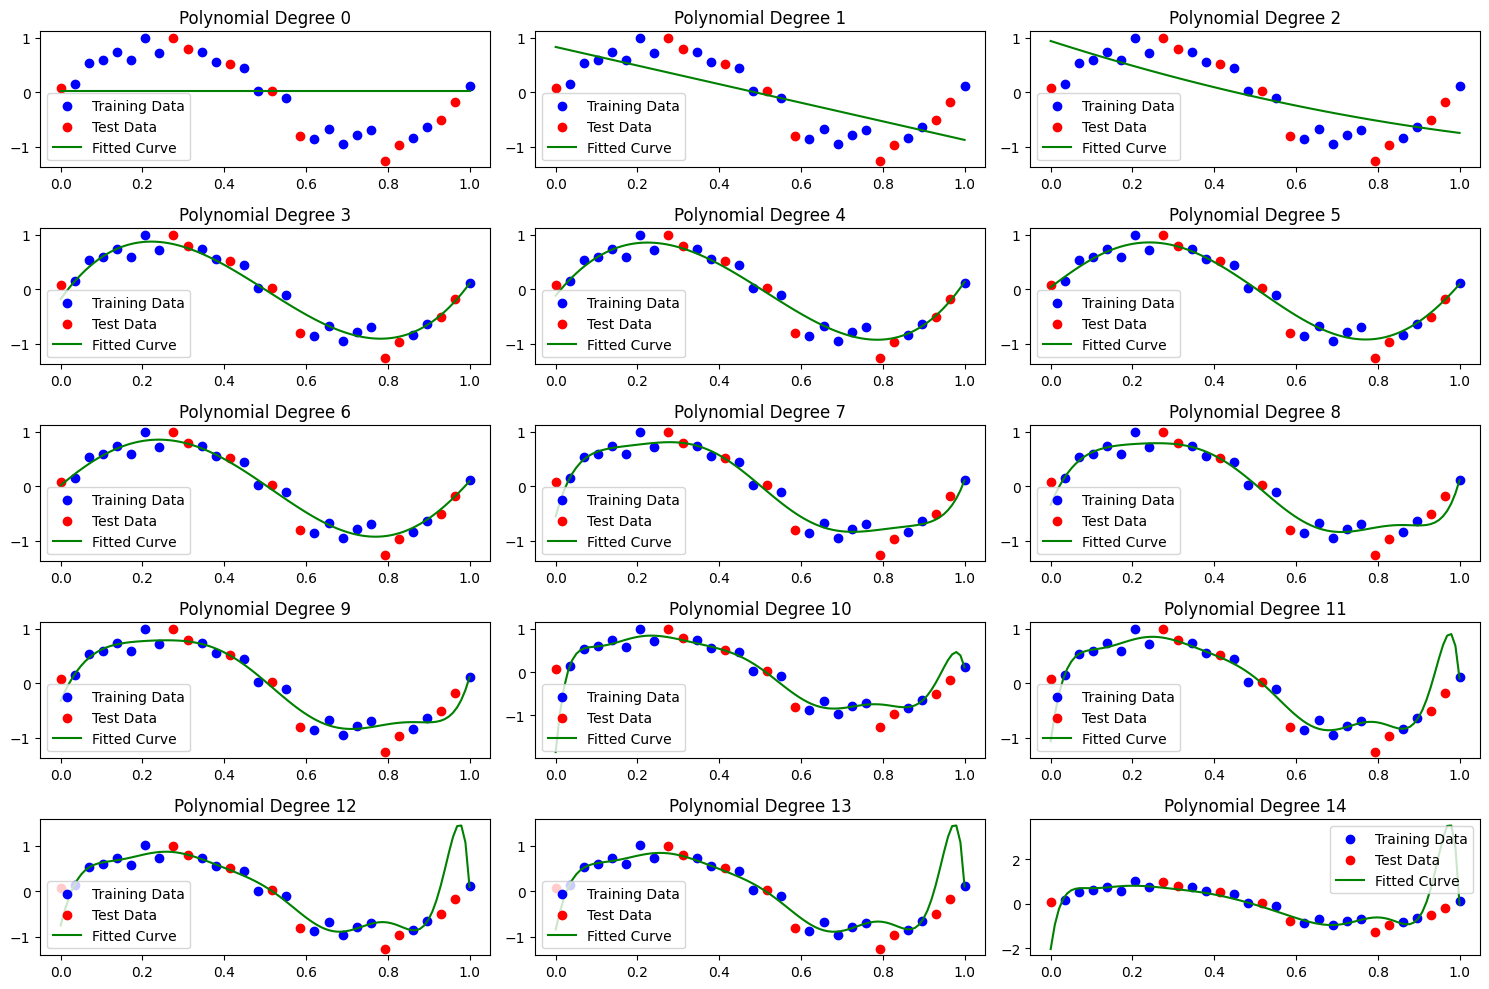

In [12]:
from sklearn.metrics import mean_squared_error

train_errors = []
test_errors = []

fig, axes = plt.subplots(5, 3, figsize=(15, 10))
axes = axes.ravel()

for degree in range(15):
    model = LeastSquares()
    poly_features = sklearn.preprocessing.PolynomialFeatures(degree=degree)
    X_train_poly = poly_features.fit_transform(X_train)
    model.fit(X_train_poly, y_train)
    train_errors.append(mean_squared_error(y_train, model.predict(X_train_poly)))
    test_errors.append(mean_squared_error(y_test, model.predict(poly_features.transform(X_test))))

    x_fit = np.linspace(0, 1, 100).reshape(-1, 1)
    y_fit = model.predict(poly_features.transform(x_fit))   
    axes[degree].scatter(X_train, y_train, color='blue', label='Training Data')
    axes[degree].scatter(X_test, y_test, color='red', label='Test Data')
    axes[degree].plot(x_fit, y_fit, color='green', label='Fitted Curve')
    axes[degree].set_title(f'Polynomial Degree {degree}')
    axes[degree].legend()   

plt.tight_layout()
plt.show()

#### Plotting train /test errors as a function of model complexity

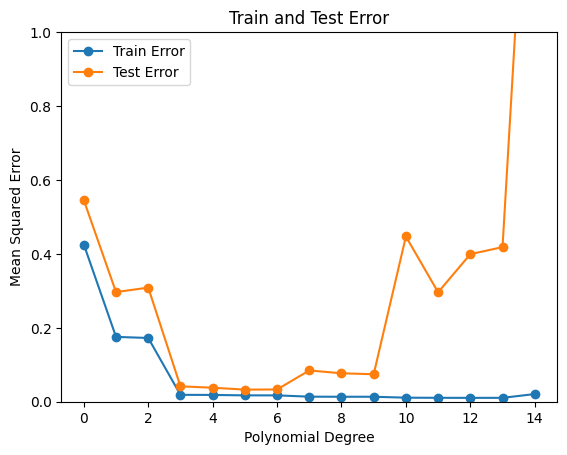

In [14]:
plt.plot(train_errors, label='Train Error', marker='o')
plt.plot(test_errors, label='Test Error', marker='o')
plt.title("Train and Test Error")
plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.ylim(0, 1)
plt.legend()
plt.show()

In [9]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [17]:
# Caricamento del dataset
bc_data = sklearn.datasets.load_breast_cancer()
print(bc_data.DESCR)

print("Classi:", bc_data.target_names)

X, y = bc_data.data, bc_data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [ ]:
# Definizione dei modelli e dei parametri per la ricerca   
models = {
    "KNN": (
        KNeighborsClassifier(),
        {"n_neighbors": [3, 5, 7, 11]}
    ),
     "DecisionTree": (
        DecisionTreeClassifier(random_state=42),
        {"max_depth": [3, 5, 10, None],
         "min_samples_split": [2, 5, 10]}
    ),
    "LogisticRegression": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("classifier", LogisticRegression(max_iter=5000))
        ]),
        {"classifier__C": [0.1, 1, 10]}
    ),
}

In [ ]:
# Ricerca parametri e valutazione dei modelli
num_folds = 5

results = {}

for name, (model, params) in models.items():
    grid = GridSearchCV(model, params, cv=num_folds, scoring="accuracy") #
    grid.fit(X_train, y_train) 

    results[name] = {
        "best_params":  grid.best_params_,
        "cv_accuracy":  grid.best_score_,
        "test_accuracy": accuracy_score(y_test, grid.predict(X_test))
    }

In [ ]:
# Report dei risultati
print(f"{'Model':<20} {'Best Params':<35} {'CV Acc':>8} {'Test Acc':>10}")
print("-" * 75)

for name, r in results.items():
    print(f"{name:<20} {str(r['best_params']):<35} {r['cv_accuracy']:>8.3f} {r['test_accuracy']:>10.3f}")

# Modello migliore
best = max(results, key=lambda k: results[k]["cv_accuracy"])
print(f"\nMiglior modello: {best} (CV accuracy: {results[best]['cv_accuracy']:.3f})")


Model                Best Params                           CV Acc   Test Acc
---------------------------------------------------------------------------
KNN                  {'n_neighbors': 7}                     0.925      0.956
DecisionTree         {'max_depth': 3, 'min_samples_split': 2}    0.932      0.947
LogisticRegression   {'classifier__C': 1}                   0.976      0.974

Miglior modello: LogisticRegression (CV accuracy: 0.976)
